In [1]:
import xarray as xr
ds = xr.open_dataset(
    r"D:\my project\Climate Modelling\data\raw\ERA5_t2m_1990_2024_punjab.nc"
)
ds

<xarray.Dataset> Size: 1MB
Dimensions:     (valid_time: 437, latitude: 29, longitude: 25)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 1990-01-01 ... 2026-05-01
    expver      (valid_time) <U4 7kB ...
  * latitude    (latitude) float64 232B 35.0 34.75 34.5 ... 28.5 28.25 28.0
  * longitude   (longitude) float64 200B 72.0 72.25 72.5 ... 77.5 77.75 78.0
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 1MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-09T17:43 GRIB to CDM+CF via cfgrib-0.9.1...

In [2]:
ds.dims

FrozenMappingWarningOnValuesAccess({'valid_time': 437, 'latitude': 29, 'longitude': 25})

In [3]:
ds.t2m.shape

(437, 29, 25)

In [4]:
ds.valid_time.max()

<xarray.DataArray 'valid_time' ()> Size: 8B
array('2026-05-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    number   int64 8B ...
Attributes:
    long_name:      time
    standard_name:  time

In [5]:
ds.valid_time.min().values

np.datetime64('1990-01-01T00:00:00.000000000')

In [6]:
print(ds.t2m.shape)
print(ds.valid_time.min().values)
print(ds.valid_time.max().values)

(437, 29, 25)
1990-01-01T00:00:00.000000000
2026-05-01T00:00:00.000000000


In [7]:
t2m_c = ds.t2m -273.15

In [8]:
#mean time series
punjab_ts = t2m_c.mean(
    dim=["latitude","longitude"]
)

punjab_ts

<xarray.DataArray 't2m' (valid_time: 437)> Size: 2kB
array([ 7.108258 ,  7.5066495, 10.74118  , 17.715216 , 23.6053   ,
       25.999878 , 24.988216 , 24.411266 , 22.7691   , 16.450716 ,
       11.478238 ,  6.3214855,  3.9694443,  7.3537655, 12.347552 ,
       16.480846 , 21.904303 , 24.655945 , 25.949879 , 24.440392 ,
       22.656853 , 16.266191 , 10.8198805,  6.733712 ,  5.743708 ,
        6.191514 , 11.737003 , 17.14191  , 21.352982 , 25.196312 ,
       24.294544 , 24.055988 , 21.16314  , 16.91056  , 11.167488 ,
        7.1927204,  3.9995189,  9.369543 , 10.627577 , 18.262634 ,
       23.780592 , 25.544992 , 24.090254 , 25.477953 , 22.193491 ,
       17.284372 , 11.437029 ,  6.4359245,  5.8293786,  6.8622117,
       13.886401 , 16.613518 , 22.950932 , 25.891983 , 24.727823 ,
       24.33105  , 21.747545 , 16.567202 , 11.556059 ,  6.433377 ,
        3.6023204,  7.5908546, 11.816964 , 17.100441 , 23.415186 ,
       26.40184  , 25.082441 , 23.452974 , 22.30171  , 17.262432 ,
       10.623158 ,  5.841348 ,  4.5407043,  8.110158 , 13.684301 ,
       18.490582 , 21.828596 , 23.776144 , 24.974628 , 23.660194 ,
       22.653683 , 15.88796  ,  9.953226 ,  5.4063582,  4.0421567,
        6.721875 , 12.069647 , 16.668217 , 20.389875 , 23.949839 ,
       25.837013 , 23.896244 , 23.032633 , 14.94566  ,  9.55155  ,
        4.7357903,  4.5807524,  7.782578 , 11.32287  , 19.028502 ,
...
       23.239325 , 25.57052  , 25.30722  , 25.520824 , 22.460493 ,
       16.473734 , 11.139918 ,  5.421287 ,  4.72799  ,  7.2364626,
       11.790563 , 19.790844 , 22.301376 , 25.464584 , 25.2998   ,
       24.935461 , 24.256624 , 17.732077 , 11.384159 ,  3.9868824,
        4.3102093,  8.203103 , 11.864277 , 17.895779 , 22.507586 ,
       25.23937  , 25.94707  , 25.650118 , 24.019226 , 18.657711 ,
       10.597377 ,  5.603633 ,  4.6662183, 10.042398 , 14.779914 ,
       17.876572 , 22.005049 , 25.056194 , 25.959011 , 25.449345 ,
       23.408346 , 18.21395  , 10.500185 ,  5.7355995,  5.0509152,
        7.854864 , 16.302893 , 22.34993  , 24.884089 , 26.042604 ,
       25.27111  , 25.02288  , 23.52547  , 17.714663 , 11.174124 ,
        6.2509017,  4.308712 , 10.505903 , 13.800349 , 17.735975 ,
       20.567373 , 24.38513  , 24.805038 , 25.908503 , 24.037094 ,
       17.60876  , 12.195593 ,  7.16769  ,  4.175745 ,  7.52882  ,
       13.20859  , 18.038774 , 24.557468 , 26.726986 , 27.021734 ,
       24.95347  , 24.018414 , 20.14689  , 13.358278 ,  5.813576 ,
        5.656285 ,  9.15873  , 13.676621 , 20.915264 , 23.938356 ,
       26.26375  , 25.444788 , 24.624672 , 23.50147  , 17.083088 ,
       10.600175 ,  7.9684777,  4.625612 , 10.230525 , 15.530251 ,
       18.949774 , 23.504913 ], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 1990-01-01 ... 2026-05-01
    expver      (valid_time) <U4 7kB ...
    number      int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [9]:
punjab_ts.shape

(437,)

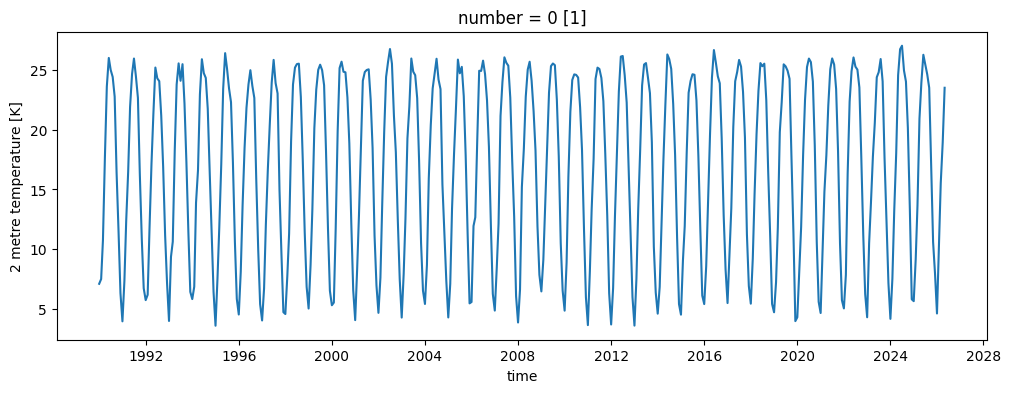

In [10]:
import matplotlib.pyplot as plt
punjab_ts.plot(figsize=(12,4))

plt.show()

In [11]:
#annual_mean
annual_ts = punjab_ts.groupby(
    "valid_time.year"
).mean()

annual_ts

<xarray.DataArray 't2m' (year: 37)> Size: 148B
array([16.591291, 16.131563, 16.012321, 16.54199 , 16.449791, 16.20764 ,
       16.080545, 15.486709, 16.766748, 17.182266, 16.937029, 16.816465,
       17.275267, 16.533987, 17.186823, 16.466856, 17.405565, 17.209988,
       16.770819, 17.039328, 17.23915 , 16.744596, 16.477762, 16.709036,
       16.387615, 16.500496, 17.741444, 17.448473, 17.001444, 16.575567,
       16.707956, 16.974398, 17.62037 , 16.918844, 17.462397, 17.40264 ,
       14.568214], dtype=float32)
Coordinates:
  * year     (year) int64 296B 1990 1991 1992 1993 1994 ... 2023 2024 2025 2026
    number   int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [12]:
annual_ts.shape

(37,)

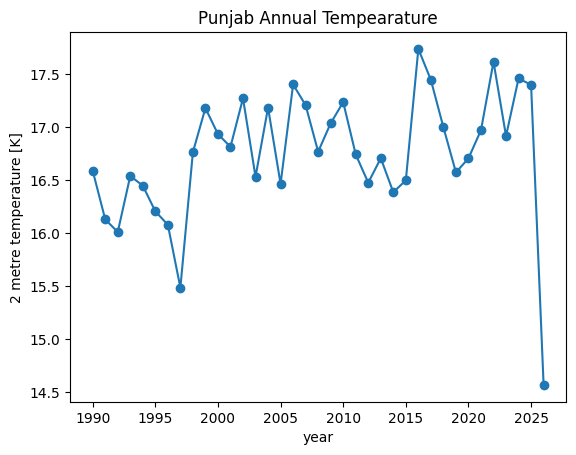

In [13]:
#plot annual teperature
annual_ts.plot(marker="o")
plt.title("Punjab Annual Tempearature")
plt.show()

In [14]:
print(ds.valid_time.min().values)
print(ds.valid_time.max().values)

punjab_ts.shape
annual_ts.shape

1990-01-01T00:00:00.000000000
2026-05-01T00:00:00.000000000


(37,)

In [16]:
year = annual_ts.year
year

<xarray.DataArray 'year' (year: 37)> Size: 296B
array([1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001,
       2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025,
       2026])
Coordinates:
  * year     (year) int64 296B 1990 1991 1992 1993 1994 ... 2023 2024 2025 2026
    number   int64 8B ...

In [20]:
import numpy as np

slope, intercept = np.polyfit(
    year,
    annual_ts.values,
    1
)

slope

np.float64(0.014679572547200027)

In [23]:
trend_line = slope*year+intercept

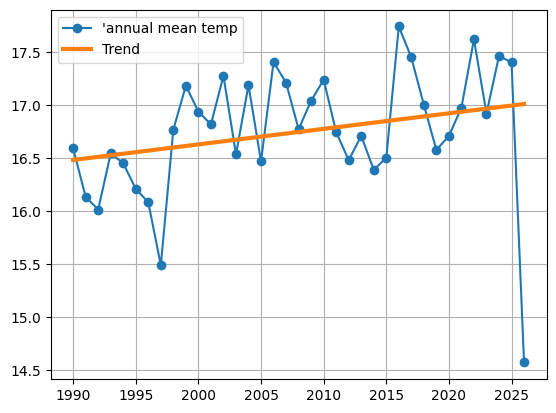

In [24]:
plt.Figure(figsize=(10,5))


plt.plot(year,annual_ts.values,marker="o",label="'annual mean temp")
plt.plot(year,trend_line,linewidth=3,label="Trend")

plt.legend()
plt.grid(True)
plt.show()


In [25]:
annual_ts = annual_ts.sel(year=slice(1990,2024))

In [26]:
print("Slope (°C/year):", slope)
print("Slope (°C/decade):", slope * 10)

Slope (°C/year): 0.014679572547200027
Slope (°C/decade): 0.14679572547200026


In [28]:
annual_ts_clean = annual_ts.sel(
    year=slice(1990, 2024)
)

annual_ts_clean.shape

(35,)

In [29]:
years = annual_ts_clean.year

slope,intercept = np.polyfit(
    years,
    annual_ts_clean.values,
    1
)
print("°C/year :", slope)
print("°C/decade :", slope * 10)

°C/year : 0.025615755716958906
°C/decade : 0.25615755716958905


In [31]:
annual_ts_clean = annual_ts.sel(year=slice(1990, 2024))
annual_ts_clean

<xarray.DataArray 't2m' (year: 35)> Size: 140B
array([16.591291, 16.131563, 16.012321, 16.54199 , 16.449791, 16.20764 ,
       16.080545, 15.486709, 16.766748, 17.182266, 16.937029, 16.816465,
       17.275267, 16.533987, 17.186823, 16.466856, 17.405565, 17.209988,
       16.770819, 17.039328, 17.23915 , 16.744596, 16.477762, 16.709036,
       16.387615, 16.500496, 17.741444, 17.448473, 17.001444, 16.575567,
       16.707956, 16.974398, 17.62037 , 16.918844, 17.462397],
      dtype=float32)
Coordinates:
  * year     (year) int64 280B 1990 1991 1992 1993 1994 ... 2021 2022 2023 2024
    number   int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [32]:
print("Warmest year:", annual_ts_clean.idxmax().values)
print("Warmest temp:", annual_ts_clean.max().values)

print("Coldest year:", annual_ts_clean.idxmin().values)
print("Coldest temp:", annual_ts_clean.min().values)

Warmest year: 2016.0
Warmest temp: 17.741444
Coldest year: 1997.0
Coldest temp: 15.486709


In [33]:
years = annual_ts_clean.year

slope, intercept = np.polyfit(
    years,
    annual_ts_clean.values,
    1
)

print("°C/year :", slope)
print("°C/decade :", slope * 10)

°C/year : 0.025615755716958906
°C/decade : 0.25615755716958905


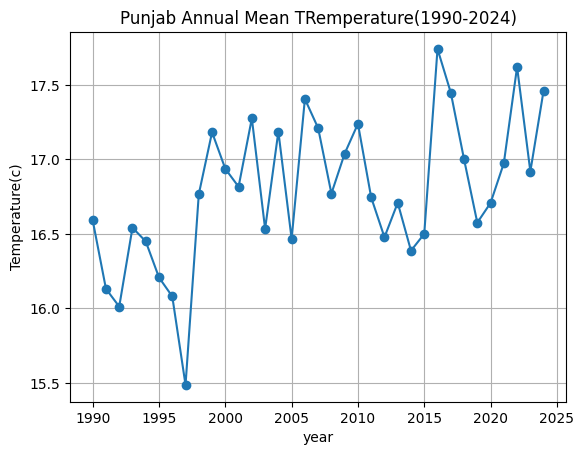

In [35]:
annual_ts_clean.plot(marker="o")

plt.title("Punjab Annual Mean TRemperature(1990-2024)")
plt.ylabel("Temperature(c)")
plt.grid(True)

plt.show()

In [36]:
climatology = annual_ts_clean.mean()

climatology

<xarray.DataArray 't2m' ()> Size: 4B
array(16.788645, dtype=float32)
Coordinates:
    number   int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [37]:
anomaly = annual_ts_clean - climatology

anomaly

<xarray.DataArray 't2m' (year: 35)> Size: 140B
array([-0.19735336, -0.6570816 , -0.7763233 , -0.24665451, -0.33885384,
       -0.5810051 , -0.70809937, -1.3019361 , -0.02189636,  0.39362144,
        0.1483841 ,  0.02782059,  0.48662186, -0.25465775,  0.3981781 ,
       -0.3217888 ,  0.6169205 ,  0.42134285, -0.01782608,  0.25068283,
        0.4505043 , -0.04404831, -0.31088257, -0.07960892, -0.4010296 ,
       -0.28814888,  0.95279884,  0.6598282 ,  0.21279907, -0.21307755,
       -0.08068848,  0.18575287,  0.8317261 ,  0.13019943,  0.67375183],
      dtype=float32)
Coordinates:
  * year     (year) int64 280B 1990 1991 1992 1993 1994 ... 2021 2022 2023 2024
    number   int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

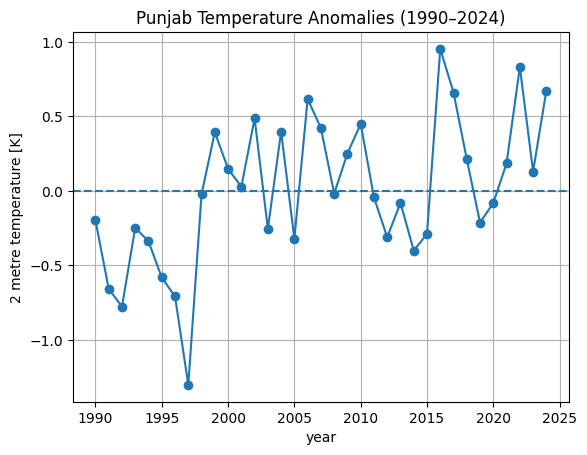

In [38]:
anomaly.plot(marker="o")
plt.axhline(0, linestyle="--")
plt.title("Punjab Temperature Anomalies (1990–2024)")
plt.grid(True)
plt.show()

In [39]:
climatology = annual_ts_clean.mean()
print(climatology.values)

anomaly = annual_ts_clean - climatology

print(anomaly.max().values)
print(anomaly.min().values)

16.788645
0.95279884
-1.3019361
